In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
GRID_POSITIONS = [
    [-1.0, -1.0], [-1.0, 0.0], [-1.0, 1.0],
    [0.0, -1.0],  [0.0, 0.0],  [0.0, 1.0],
    [1.0, -1.0],  [1.0, 0.0],  [1.0, 1.0]
]
MEANS = torch.tensor(GRID_POSITIONS, dtype=torch.float32)
STD_DEV = 0.05

BATCH_SIZE = 512
N_STEPS = 50
N_EPOCHS = 5000
LR = 1e-3

N_SAMPLES = 5000

MODE_THRESHOLD = 1 * STD_DEV      
DEAD_ZONE_THRESHOLD = 3 * STD_DEV 

In [4]:
print("STEP 1.2 - TEST B: 2D GRID (3×3 = 9 GAUSSIANS)")

print(f"Grid positions: 3×3 grid centered at origin")
print(f"Std Dev: {STD_DEV}")
print(f"Mode Region: distance to nearest μ < {MODE_THRESHOLD}")
print(f"Dead Zone: distance to nearest μ > {DEAD_ZONE_THRESHOLD}")

STEP 1.2 - TEST B: 2D GRID (3×3 = 9 GAUSSIANS)
Grid positions: 3×3 grid centered at origin
Std Dev: 0.05
Mode Region: distance to nearest μ < 0.05
Dead Zone: distance to nearest μ > 0.15000000000000002


In [ ]:
def get_region(x, return_distance=False):

    distances = torch.sqrt(((MEANS - torch.tensor(x)) ** 2).sum(dim=1))
    min_dist = distances.min().item()
    
    if min_dist < MODE_THRESHOLD:
        region = "Mode"
    elif min_dist > DEAD_ZONE_THRESHOLD:
        region = "DeadZone"
    else:
        region = "Transition"
    
    if return_distance:
        return region, min_dist
    return region

In [6]:
def get_batch(batch_size):
    """Generate batch from 9-component 2D Gaussian mixture."""
    indices = torch.randint(0, 9, (batch_size,))
    means = MEANS[indices]  
    noise = torch.randn_like(means) * STD_DEV
    data = means + noise
    return data

In [7]:
class SimpleDiffusionNet2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),  
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 2)  
        )
    
    def forward(self, x, t):
        t_input = (t.view(-1, 1) / N_STEPS) * 2 - 1
        inp = torch.cat([x, t_input], dim=1)
        return self.net(inp)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nTraining on: {device}")

model = SimpleDiffusionNet2D().to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=N_EPOCHS)

betas = torch.linspace(1e-4, 0.02, N_STEPS).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(f"Training for {N_EPOCHS} epochs...")
for epoch in tqdm(range(N_EPOCHS), desc="Training"):
    optimizer.zero_grad()
    x0 = get_batch(BATCH_SIZE).to(device)
    t = torch.randint(0, N_STEPS, (BATCH_SIZE,)).to(device)
    noise = torch.randn_like(x0)
    
    a_bar = alphas_cumprod[t].view(-1, 1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    
    noise_pred = model(xt, t)
    loss = nn.MSELoss()(noise_pred, noise)
    
    loss.backward()
    optimizer.step()
    scheduler.step()

print("Training complete!\n")



Training on: cuda
Training for 5000 epochs...


Training: 100%|██████████| 5000/5000 [00:39<00:00, 125.29it/s]

Training complete!



In [ ]:
print(f"Generating {N_SAMPLES} samples with trajectory tracking...")
model.eval()

xt = torch.randn(N_SAMPLES, 2).to(device)  
trajectory_stack = []

with torch.no_grad():
    for i in reversed(range(N_STEPS)):
        t = torch.full((N_SAMPLES,), i, dtype=torch.long).to(device)
        noise_pred = model(xt, t)
        
        a_bar = alphas_cumprod[t].view(-1, 1)
        x0_pred = (xt - torch.sqrt(1 - a_bar) * noise_pred) / torch.sqrt(a_bar)
        
        trajectory_stack.append(x0_pred.cpu().float().numpy())
        
        if i > 0:
            noise = torch.randn_like(xt)
            beta = betas[t].view(-1, 1)
            alpha = alphas[t].view(-1, 1)
            xt = (xt - (beta / torch.sqrt(1 - a_bar)) * noise_pred) / torch.sqrt(alpha) + torch.sqrt(beta) * noise
        else:
            xt = x0_pred

trajectories = np.array(trajectory_stack).transpose(1, 0, 2)
final_samples = trajectories[:, -1, :] 

print("Sampling complete!\n")

Generating 5000 samples with trajectory tracking...
✓ Sampling complete!



In [10]:
print("VARIANCE ANALYSIS (Last 15 Steps)")

start_idx = N_STEPS - 15
end_idx = N_STEPS


variances = []
for sample_idx in range(N_SAMPLES):
    trajectory_window = trajectories[sample_idx, start_idx:end_idx, :]  

    var_x = np.var(trajectory_window[:, 0].astype(np.float32))
    var_y = np.var(trajectory_window[:, 1].astype(np.float32))
    avg_var = (var_x + var_y) / 2
    variances.append(avg_var)

variances = np.array(variances)

mode_vars = []
dead_vars = []
transition_vars = []

for i, sample in enumerate(final_samples):
    region = get_region(sample)
    if region == "Mode":
        mode_vars.append(variances[i])
    elif region == "DeadZone":
        dead_vars.append(variances[i])
    else:
        transition_vars.append(variances[i])
        
if len(mode_vars) > 0 and len(dead_vars) > 0:
    mean_mode_var = np.mean(mode_vars)
    mean_dead_var = np.mean(dead_vars)
    ratio = mean_dead_var / mean_mode_var if mean_mode_var > 0 else 0
else:
    ratio = 0
    mean_mode_var = np.mean(mode_vars) if mode_vars else 0
    mean_dead_var = np.mean(dead_vars) if dead_vars else 0

VARIANCE ANALYSIS (Last 15 Steps)


In [11]:
print(f"\nSample Distribution:")
print(f"  Mode samples: {len(mode_vars)} ({100*len(mode_vars)/N_SAMPLES:.1f}%)")
print(f"  Dead Zone samples: {len(dead_vars)} ({100*len(dead_vars)/N_SAMPLES:.1f}%)")
print(f"  Transition samples: {len(transition_vars)} ({100*len(transition_vars)/N_SAMPLES:.1f}%)")

print(f"\nVariance Statistics:")
print(f"  Mean variance (Mode): {mean_mode_var:.6f}")
print(f"  Mean variance (Dead): {mean_dead_var:.6f}")

print(f"RATIO: {ratio:.2f}")
print(f"THRESHOLD: 5.0")
print(f"STATUS: {'PASS' if ratio > 5.0 else 'FAIL'}")


Sample Distribution:
  Mode samples: 1717 (34.3%)
  Dead Zone samples: 221 (4.4%)
  Transition samples: 3062 (61.2%)

Variance Statistics:
  Mean variance (Mode): 0.001534
  Mean variance (Dead): 0.008514
RATIO: 5.55
THRESHOLD: 5.0
STATUS: PASS



Visualization saved to: step1_2_test_b_2d_grid.png


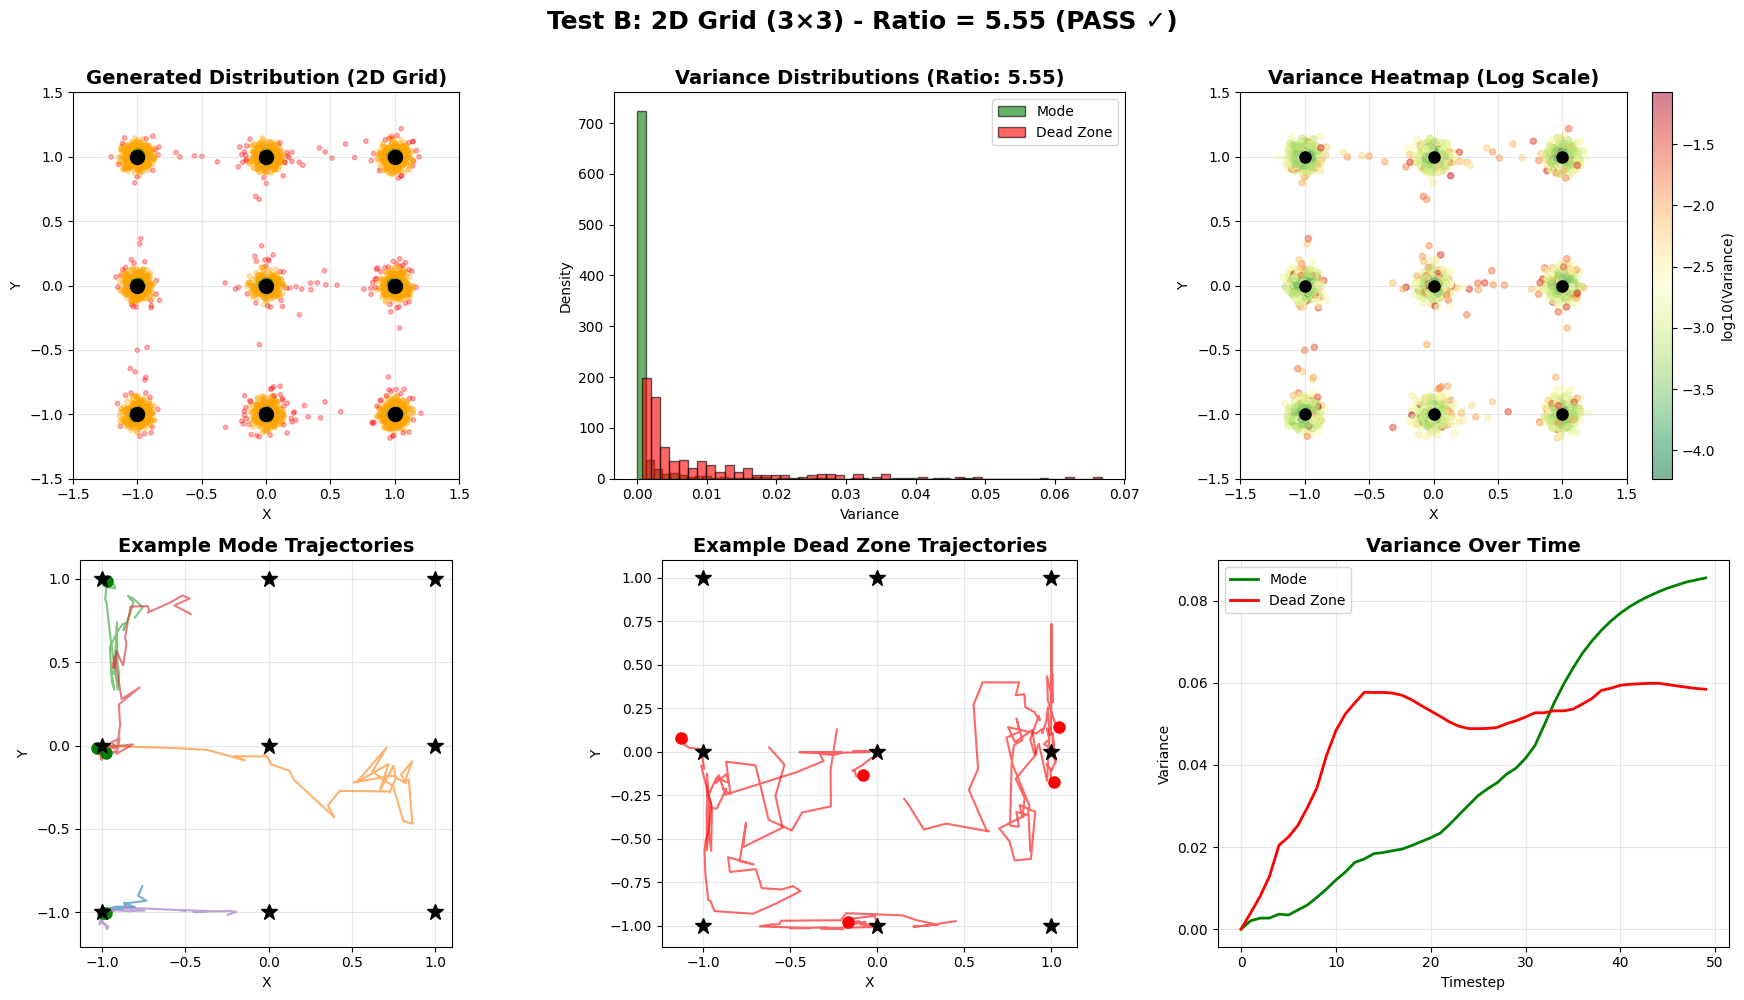

In [12]:
fig = plt.figure(figsize=(18, 10))

ax1 = plt.subplot(2, 3, 1)
colors = ['green' if get_region(s) == "Mode" else 'red' if get_region(s) == "DeadZone" else 'orange' 
          for s in final_samples]
ax1.scatter(final_samples[:, 0], final_samples[:, 1], c=colors, alpha=0.3, s=10)

for mean in MEANS:
    ax1.plot(mean[0], mean[1], 'ko', markersize=10)
    circle = plt.Circle((mean[0], mean[1]), MODE_THRESHOLD, color='green', fill=False, linestyle='--')
    ax1.add_patch(circle)

ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')
ax1.set_title("Generated Distribution (2D Grid)", fontsize=14, fontweight='bold')
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.grid(alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
if mode_vars and dead_vars:
    ax2.hist(mode_vars, bins=50, alpha=0.6, label='Mode', density=True, color='green', edgecolor='black')
    ax2.hist(dead_vars, bins=50, alpha=0.6, label='Dead Zone', density=True, color='red', edgecolor='black')
    ax2.legend()
ax2.set_title(f"Variance Distributions (Ratio: {ratio:.2f})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Variance")
ax2.set_ylabel("Density")

ax3 = plt.subplot(2, 3, 3)
scatter = ax3.scatter(final_samples[:, 0], final_samples[:, 1], 
                      c=np.log10(variances + 1e-10), cmap='RdYlGn_r', 
                      alpha=0.5, s=20)
for mean in MEANS:
    ax3.plot(mean[0], mean[1], 'ko', markersize=8)
plt.colorbar(scatter, ax=ax3, label='log10(Variance)')
ax3.set_xlim(-1.5, 1.5)
ax3.set_ylim(-1.5, 1.5)
ax3.set_aspect('equal')
ax3.set_title("Variance Heatmap (Log Scale)", fontsize=14, fontweight='bold')
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.grid(alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
mode_indices = [i for i, s in enumerate(final_samples) if get_region(s) == "Mode"][:5]
for idx in mode_indices:
    traj = trajectories[idx]
    ax4.plot(traj[:, 0], traj[:, 1], alpha=0.6, linewidth=1.5)
    ax4.plot(traj[-1, 0], traj[-1, 1], 'go', markersize=8)
for mean in MEANS:
    ax4.plot(mean[0], mean[1], 'k*', markersize=12)
ax4.set_title("Example Mode Trajectories", fontsize=14, fontweight='bold')
ax4.set_xlabel("X")
ax4.set_ylabel("Y")
ax4.grid(alpha=0.3)
ax4.set_aspect('equal')

ax5 = plt.subplot(2, 3, 5)
dead_indices = [i for i, s in enumerate(final_samples) if get_region(s) == "DeadZone"][:5]
if dead_indices:
    for idx in dead_indices:
        traj = trajectories[idx]
        ax5.plot(traj[:, 0], traj[:, 1], alpha=0.6, linewidth=1.5, color='red')
        ax5.plot(traj[-1, 0], traj[-1, 1], 'ro', markersize=8)
    for mean in MEANS:
        ax5.plot(mean[0], mean[1], 'k*', markersize=12)
    ax5.set_title("Example Dead Zone Trajectories", fontsize=14, fontweight='bold')
else:
    ax5.text(0.5, 0.5, "No Dead Zone Samples", ha='center', va='center', transform=ax5.transAxes)
ax5.set_xlabel("X")
ax5.set_ylabel("Y")
ax5.grid(alpha=0.3)
ax5.set_aspect('equal')

ax6 = plt.subplot(2, 3, 6)
if mode_indices:
    mode_vars_time = np.mean([np.mean(np.var(trajectories[i, :, :], axis=1)) 
                               for i in mode_indices[:50]])
    mode_vars_timeline = [np.mean(np.var(trajectories[mode_indices, :t, :], axis=1)) 
                          for t in range(1, N_STEPS+1)]
    ax6.plot(mode_vars_timeline, label='Mode', color='green', linewidth=2)

if dead_indices:
    dead_vars_timeline = [np.mean(np.var(trajectories[dead_indices, :t, :], axis=1)) 
                          for t in range(1, N_STEPS+1)]
    ax6.plot(dead_vars_timeline, label='Dead Zone', color='red', linewidth=2)

ax6.set_title("Variance Over Time", fontsize=14, fontweight='bold')
ax6.set_xlabel("Timestep")
ax6.set_ylabel("Variance")
ax6.legend()
ax6.grid(alpha=0.3)

fig.suptitle(f'Test B: 2D Grid (3×3) - Ratio = {ratio:.2f} ({"PASS ✓" if ratio > 5.0 else "FAIL ✗"})', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('Phase1_Part2_Grid.png', dpi=200, bbox_inches='tight')
print("\nVisualization saved to: step1_2_test_b_2d_grid.png")
plt.show()